<a href="https://colab.research.google.com/github/iamLayan/AI-story-recommendation/blob/main/Hotel_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')

In [3]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
df.shape

(119390, 32)

In [7]:
#Missing value

# calculate nulls for each column
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [8]:
df.isnull().mean() * 100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


In [9]:
df.drop('company',axis=1)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [10]:
df['agent']= df['agent'].fillna(0)

In [11]:
df['agent']

,agent
0,0.0
1,0.0
2,0.0
3,304.0
4,240.0
...,...
119385,394.0
119386,9.0
119387,9.0
119388,89.0


In [12]:
df['children'].min(),df['children'].max()


(0.0, 10.0)

In [13]:
df['children']=df['children'].fillna(df['children'].median())

In [14]:
df['children'].describe()

,children
count,119390.000000
mean,0.103886
std,0.398555
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10.000000


In [15]:
df['country']

,country
0,PRT
1,PRT
2,GBR
3,GBR
4,GBR
...,...
119385,BEL
119386,FRA
119387,DEU
119388,GBR


In [16]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [17]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [18]:
# duplicated rows

df.duplicated().sum()

np.int64(32013)

In [19]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [20]:
df.drop_duplicates()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [21]:
# DATA TYPE
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

In [22]:
df["is_canceled"] = df["is_canceled"].astype(bool)
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,False,342,2015,July,27,1,0,0,2,...,0.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,False,737,2015,July,27,1,0,0,2,...,0.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,False,7,2015,July,27,1,0,1,1,...,0.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,False,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,False,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,False,23,2017,August,35,30,2,5,2,...,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06,2017-08-30
119386,City Hotel,False,102,2017,August,35,31,2,5,3,...,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07,2017-08-31
119387,City Hotel,False,34,2017,August,35,31,2,5,2,...,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07,2017-08-31
119388,City Hotel,False,109,2017,August,35,31,2,5,2,...,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07,2017-08-31


In [23]:
df= df.drop(['arrival_date_year',
         'arrival_date_day_of_month','company'],axis=1)

In [24]:
df["has_children"] = (df["children"] + df["babies"]) > 0

In [25]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

In [26]:
df['total_nights']=df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_nights'].describe()

,total_nights
count,119390.000000
mean,3.427900
std,2.557439
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,69.000000


In [27]:
df = df[df["total_nights"] > 0]
df.drop(df[df["total_nights"] <= 0 ].index, inplace=True)

In [28]:
df = df[df["adr"] > 0]
df.drop(df[df["adr"] <= 0 ].index, inplace=True)

In [29]:
df['total_cost']=df['adr']*df['total_nights']

In [30]:
df[df['adr'] <1]


,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,has_children,total_guests,total_nights,total_cost
35059,Resort Hotel,False,80,March,10,12,26,2,0.0,0,...,0.26,0,0,Check-Out,2017-04-12,2017-03-05,False,2.0,38,9.88
47427,City Hotel,True,37,February,8,4,8,1,0.0,0,...,0.50,0,0,Canceled,2016-01-18,2016-02-20,False,1.0,12,6.00


In [31]:
df['adr'].describe()

,adr
count,117430.000000
mean,103.530818
std,49.198721
min,0.260000
25%,70.530000
50%,95.000000
75%,126.000000
max,5400.000000


In [32]:
df['total_cost'].describe()

,total_cost
count,117430.000000
mean,363.821522
std,335.477966
min,1.000000
25%,151.000000
50%,270.000000
75%,450.000000
max,7590.000000


In [33]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_guests', 'total_nights',
       'total_cost'],
      dtype='object')

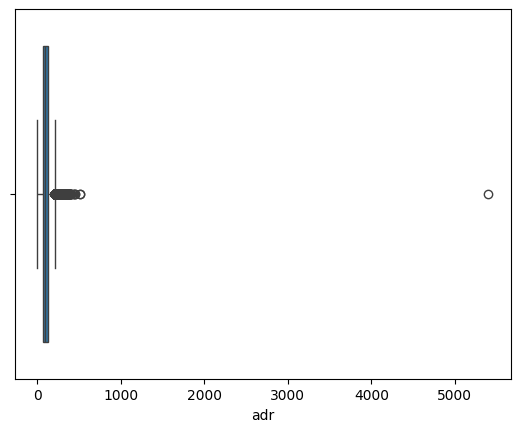

In [34]:
sns.boxplot(x=df["adr"])
plt.show()

In [35]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-12.674999999999997 209.20499999999998


In [36]:
outliers = df[(df["adr"] < lower) | (df["adr"] > upper)]

len(outliers)

4050

In [37]:
df["adr"].sort_values(ascending=False).head(20)

,adr
48515,5400.00
111403,510.00
15083,508.00
103912,451.50
13142,450.00
13391,437.00
39155,426.25
39568,402.00
39118,397.38
13323,392.00


In [38]:
df[df["adr"] == 5400]

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,has_children,total_guests,total_nights,total_cost
48515,City Hotel,True,35,March,13,0,1,2,0.0,0,...,5400.0,0,0,Canceled,2016-02-19,2016-03-25,False,2.0,1,5400.0


In [39]:
df = df.drop(index=48515)

In [40]:
df

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,has_children,total_guests,total_nights,total_cost
2,Resort Hotel,False,7,July,27,0,1,1,0.0,0,...,75.00,0,0,Check-Out,2015-07-02,2015-07-01,False,1.0,1,75.00
3,Resort Hotel,False,13,July,27,0,1,1,0.0,0,...,75.00,0,0,Check-Out,2015-07-02,2015-07-01,False,1.0,1,75.00
4,Resort Hotel,False,14,July,27,0,2,2,0.0,0,...,98.00,0,1,Check-Out,2015-07-03,2015-07-01,False,2.0,2,196.00
5,Resort Hotel,False,14,July,27,0,2,2,0.0,0,...,98.00,0,1,Check-Out,2015-07-03,2015-07-01,False,2.0,2,196.00
6,Resort Hotel,False,0,July,27,0,2,2,0.0,0,...,107.00,0,0,Check-Out,2015-07-03,2015-07-01,False,2.0,2,214.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,False,23,August,35,2,5,2,0.0,0,...,96.14,0,0,Check-Out,2017-09-06,2017-08-30,False,2.0,7,672.98
119386,City Hotel,False,102,August,35,2,5,3,0.0,0,...,225.43,0,2,Check-Out,2017-09-07,2017-08-31,False,3.0,7,1578.01
119387,City Hotel,False,34,August,35,2,5,2,0.0,0,...,157.71,0,4,Check-Out,2017-09-07,2017-08-31,False,2.0,7,1103.97
119388,City Hotel,False,109,August,35,2,5,2,0.0,0,...,104.40,0,0,Check-Out,2017-09-07,2017-08-31,False,2.0,7,730.80


In [41]:
#EDA
df['hotel'].value_counts()

,count
hotel,
City Hotel,78121
Resort Hotel,39308


In [42]:
df['is_canceled'].value_counts()

,count
is_canceled,
False,73419
True,44010


In [43]:
df['customer_type'].value_counts()

,count
customer_type,
Transient,88162
Transient-Party,24671
Contract,4052
Group,544


In [44]:
df.groupby("is_canceled")["lead_time"].mean()

,lead_time
is_canceled,
False,81.035781
True,145.204567


In [45]:
df.groupby("total_cost")["lead_time"].mean()

,lead_time
total_cost,
1.00,115.000000
2.00,15.285714
2.96,11.000000
3.00,65.500000
4.00,18.466667
...,...
4967.70,65.000000
6148.00,16.000000
6300.00,378.000000


Is there a relationship between booking lead time and room price?


In [46]:
df.groupby('lead_time')['adr'].mean()

,adr
lead_time,
0,91.566223
1,94.699595
2,97.671426
3,96.831396
4,98.820601
...,...
615,61.647059
622,61.647059
626,62.800000


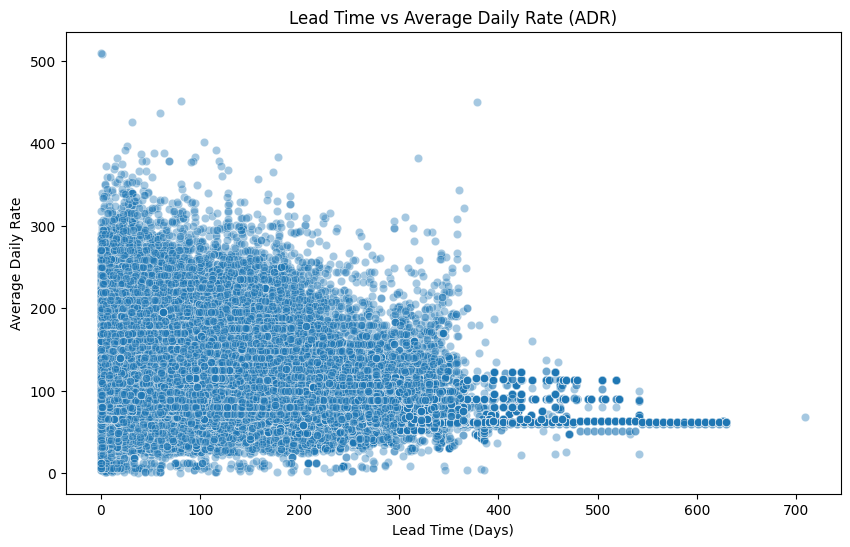

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="lead_time", y="adr", alpha=0.4)

plt.title("Lead Time vs Average Daily Rate (ADR)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Average Daily Rate")
plt.show()

There is no strong relationship between booking lead time and room price.

Does the number of guests affect the room price?

In [48]:
df.groupby("total_guests")["adr"].mean()

,adr
total_guests,
0.0,60.715161
1.0,84.764494
2.0,98.948040
3.0,144.986272
4.0,188.084444
5.0,220.415076
10.0,95.000000
12.0,108.805000


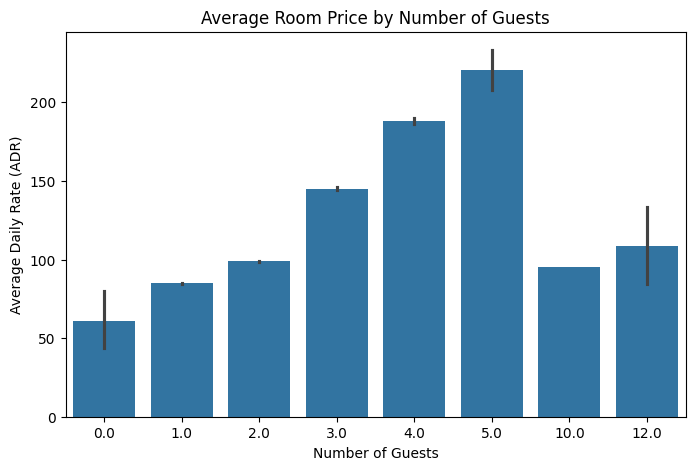

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="total_guests", y="adr", estimator="mean")

plt.title("Average Room Price by Number of Guests")
plt.xlabel("Number of Guests")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

In [50]:
df["total_guests"].value_counts().sort_index()

,count
total_guests,
0.0,31
1.0,21725
2.0,81238
3.0,10407
4.0,3893
5.0,132
10.0,1
12.0,2


<Axes: xlabel='total_guests', ylabel='adr'>

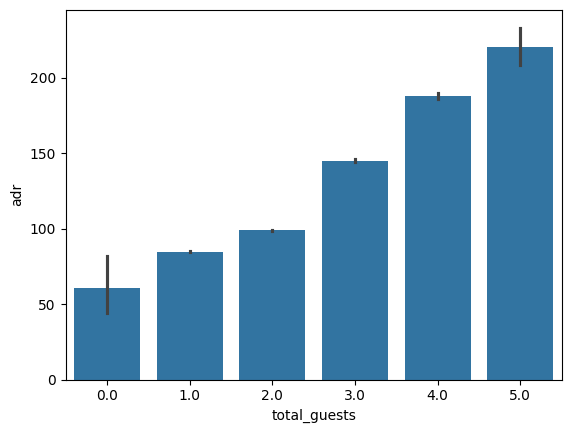

In [51]:
plot_df = df[df["total_guests"] <= 5]

sns.barplot(data=plot_df, x="total_guests", y="adr", estimator="mean")

The average room price generally increases as the number of guests increases from one to five guests. However, categories with 10 and 12 guests contain very few bookings.



Does the meal type affect the room price?

In [52]:
df.groupby("meal")["adr"].mean().sort_values(ascending=False)

,adr
meal,
HB,122.002575
FB,111.271483
BB,100.986317
SC,100.263481
Undefined,95.037639


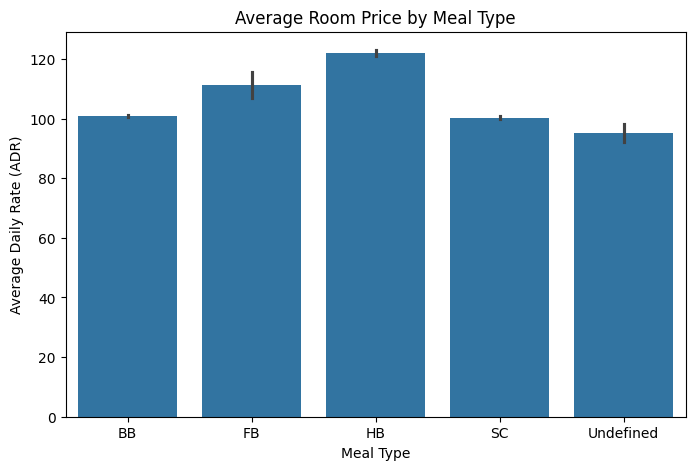

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="meal", y="adr", estimator="mean")

plt.title("Average Room Price by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

Half Board (HB) has the highest average room price, followed by Full Board (FB). This suggests that bookings including more meal services tend to have higher room rates.

Do special requests affect the room price?



In [54]:
df.groupby("total_of_special_requests")["adr"].mean().sort_values(ascending=False)

,adr
total_of_special_requests,
4,137.016543
5,127.746500
3,126.947369
2,118.922418
1,110.109488
0,96.502943


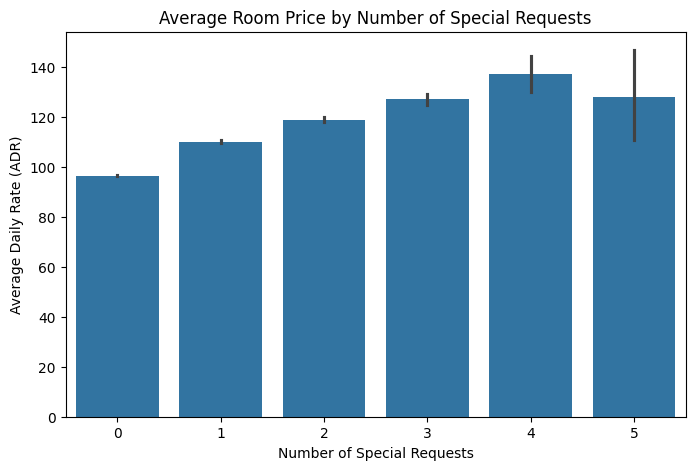

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x="total_of_special_requests",
            y="adr",
            estimator="mean")

plt.title("Average Room Price by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

In [56]:
df["total_of_special_requests"].value_counts().sort_index()

,count
total_of_special_requests,
0,69139
1,32727
2,12763
3,2436
4,324
5,40


The average room price generally increases as the number of special requests increases. However, bookings with five special requests are relatively few.

Does requesting a parking space affect the room price?

In [57]:
df.groupby("required_car_parking_spaces")["adr"].mean()

,adr
required_car_parking_spaces,
0,102.734197
1,114.813674
2,117.203929
3,120.110000
8,60.000000


In [58]:
df["required_car_parking_spaces"].value_counts().sort_index()

,count
required_car_parking_spaces,
0,110121
1,7275
2,28
3,3
8,2


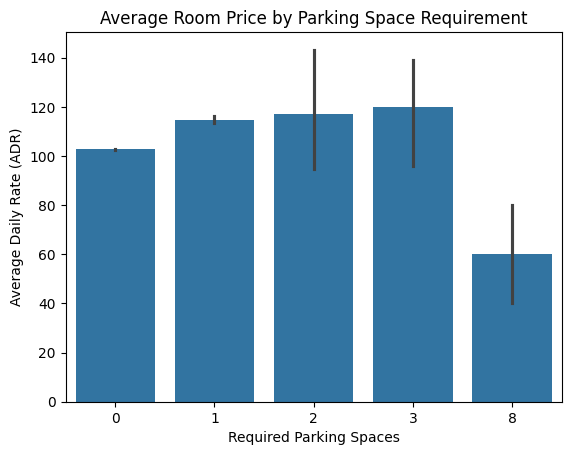

In [59]:
sns.barplot(
    data=df,
    x="required_car_parking_spaces",
    y="adr",
    estimator="mean"
)

plt.title("Average Room Price by Parking Space Requirement")
plt.xlabel("Required Parking Spaces")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

The average room price increases for guests requesting one to three parking spaces. However, the category with eight parking spaces contains only two bookings, so it is considered an outlier and should not be used to draw general conclusions.

Does customer type affect the average length of stay?



In [60]:
df.groupby("customer_type")["total_nights"].mean()

,total_nights
customer_type,
Contract,5.342300
Group,2.797794
Transient,3.483065
Transient-Party,3.071906


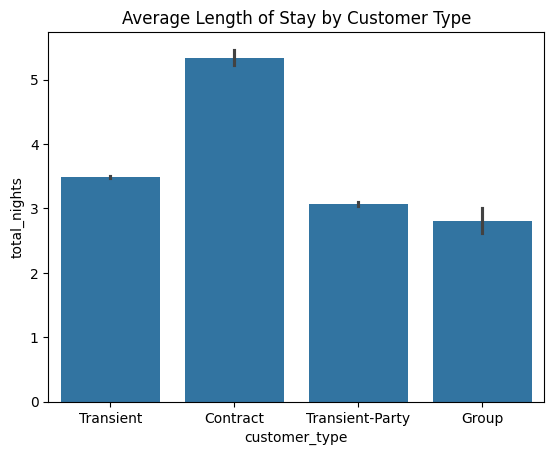

In [61]:
sns.barplot(data=df, x="customer_type", y="total_nights", estimator="mean")
plt.title("Average Length of Stay by Customer Type")
plt.show()

Contract customers have the longest average stay, while Group customers have the shortest average stay. This suggests that customer type is associated with the length of stay.

Which months have the highest average room prices?


In [62]:
months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=months,
    ordered=True
)

In [63]:
monthly_price = df.groupby("arrival_date_month")["adr"].mean()

/tmp/ipykernel_1122/3617056990.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_price = df.groupby("arrival_date_month")["adr"].mean()


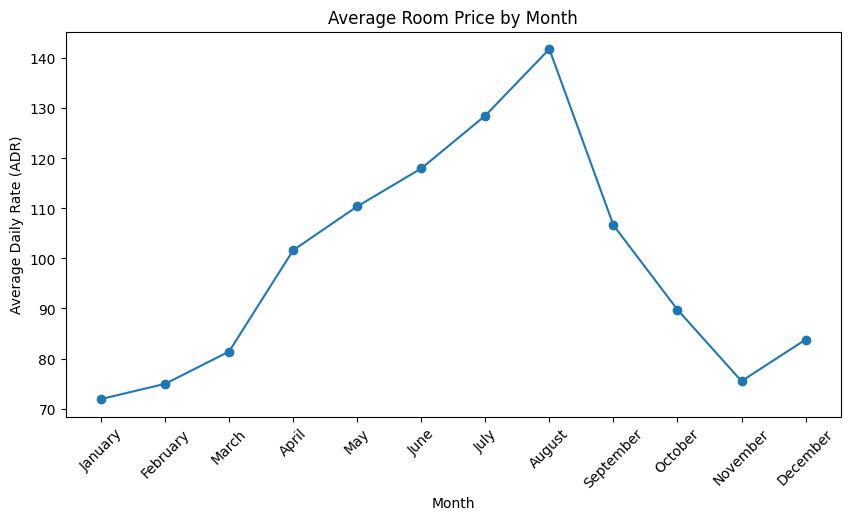

In [64]:
plt.figure(figsize=(10,5))
plt.plot(monthly_price.index, monthly_price.values, marker="o")

plt.title("Average Room Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate (ADR)")
plt.xticks(rotation=45)

plt.show()